
# Causal Inference for the Energy Industry

**A hands-on project based on Chapter 1 of *Causal Inference for Data Science*
(De Villa, Manning, 2025)**

Utilities, grid operators, and energy-efficiency programs constantly face
causal questions:

- Did our **peak-demand alert program** actually reduce electricity use, or
  did usage just look different because alerts are only sent on unusually
  hot days?
- Does installing a **smart thermostat** cause lower monthly energy
  consumption, or do the customers who adopt smart thermostats just happen
  to live in newer, better-insulated (naturally lower-usage) homes?
- Are two energy trends **causally related**, or just riding the same
  underlying wave (e.g., rising household income / environmental
  awareness)?

This notebook works through two energy case studies using the exact 5-step
causal workflow and concepts from Chapter 1, with a twist: in the tourism
and economics projects, naive estimates tended to **overstate** the true
effect. Here we'll see a case where the naive estimate **understates** it —
confounding bias can push your estimate in *either* direction, which is
exactly why the book insists you can't just eyeball a correlation.

1. **Case Study A** — a before/after time-series problem (mirrors the
   book's "deploying a new website" example, section 1.3.1), applied to a
   utility's peak-demand alert program, confounded by **temperature**.
2. **Case Study B** — a cross-sectional confounding problem (mirrors
   section 1.4.2's age/treatment/recovery DAG), applied to whether
   **smart thermostats** reduce energy consumption, confounded by **home
   size**.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(4242)
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3



## Case Study A — Did the Peak Alert program actually cut electricity use?

### The scenario

A utility sends **"Peak Alert"** texts asking customers to cut back on
electricity use, but only on days the grid operator forecasts will be
unusually hot (and therefore high-demand — think air conditioning load).
A data analyst compares average electricity use **on alert days vs.
non-alert days** and is surprised to find alert days look like they use
*more* electricity, not less. Does the program not work — or even
backfire?

This is exactly the trap from section 1.3.1: the analyst is comparing two
groups (alert days / non-alert days) that differ in something else besides
the intervention — here, **temperature**, which is a confounder:

```
             Temperature (confounder)
             /                    \
            v                      v
   Peak Alert issued?  -------> Electricity demand
```

Hot days *cause* both (a) the utility to issue an alert, and (b) higher
electricity demand (more A/C use) — regardless of whether the alert
worked. If we don't adjust for temperature, the true conservation effect
of the alert can be completely hidden, or even flipped in sign.


In [2]:

n_days = 3000

# Confounder: daily high temperature (Fahrenheit), summer range
temperature = np.random.uniform(70, 105, size=n_days)

# Alerts are issued specifically on the hottest days (selection into "treatment")
prob_alert = 1 / (1 + np.exp(-0.35 * (temperature - 92)))
alert_issued = np.random.binomial(1, prob_alert)

# True causal effect of the alert: reduces demand by 400 MWh on the day it's issued
TRUE_ALERT_EFFECT = -400

electricity_demand = (
    8000
    + 90 * temperature              # hotter days -> much higher demand (A/C load)
    + TRUE_ALERT_EFFECT * alert_issued   # <-- the causal effect we want to recover
    + np.random.normal(0, 300, size=n_days)
)

grid = pd.DataFrame({
    'temperature': temperature,
    'alert_issued': alert_issued,
    'electricity_demand': electricity_demand
})
grid.head()


,temperature,alert_issued,electricity_demand
0,81.373232,0,15038.992032
1,102.914510,1,16775.567708
2,101.990278,1,16870.124593
3,80.027828,0,15078.658433
4,97.363092,1,16676.985769


In [3]:

naive_alert_effect = (grid.loc[grid.alert_issued == 1, 'electricity_demand'].mean()
                       - grid.loc[grid.alert_issued == 0, 'electricity_demand'].mean())

print(f"E[demand | alert issued]     = {grid.loc[grid.alert_issued==1,'electricity_demand'].mean():.0f} MWh")
print(f"E[demand | no alert]         = {grid.loc[grid.alert_issued==0,'electricity_demand'].mean():.0f} MWh")
print(f"Naive difference             = {naive_alert_effect:+.0f} MWh")
print(f"True causal effect of alert  = {TRUE_ALERT_EFFECT:+.0f} MWh")


E[demand | alert issued]     = 16390 MWh
E[demand | no alert]         = 15336 MWh
Naive difference             = +1054 MWh
True causal effect of alert  = -400 MWh



The naive comparison shows demand is **higher**, not lower, on alert days —
which would make it look like the program doesn't work, or is even
counterproductive. But this is entirely because alerts are targeted at the
hottest days, which drive demand up independently of any conservation
behavior. The true effect (a **400 MWh reduction**) is completely masked.
This is the flip side of the tourism/economics examples: here, confounding
doesn't just inflate an effect — it can **hide a real effect entirely, or
reverse its apparent sign.**


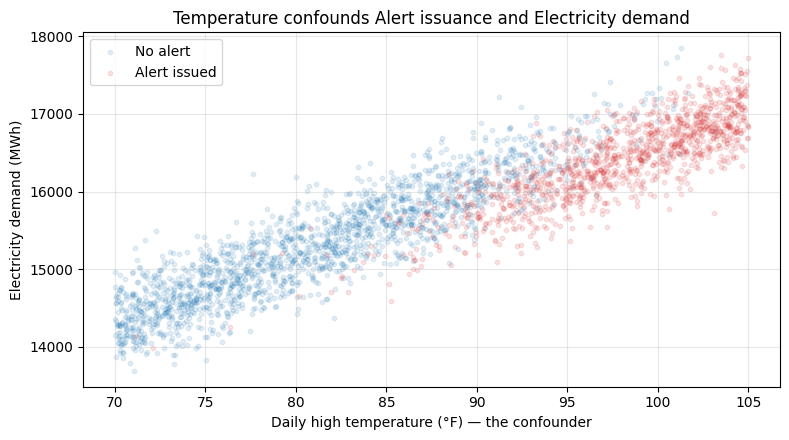

In [4]:

fig, ax = plt.subplots()
for t, color, label in [(0, '#1f77b4', 'No alert'), (1, '#d62728', 'Alert issued')]:
    subset = grid[grid.alert_issued == t]
    ax.scatter(subset.temperature, subset.electricity_demand, alpha=0.12, s=10,
               color=color, label=label)
ax.set_xlabel('Daily high temperature (°F) — the confounder')
ax.set_ylabel('Electricity demand (MWh)')
ax.set_title('Temperature confounds Alert issuance and Electricity demand')
ax.legend()
plt.tight_layout()
plt.show()



### Adjusting for temperature

Following the same adjustment logic as before: compare alert vs. no-alert
days **within narrow temperature bands** — apples to apples — then average
the within-band effects back up.


In [5]:

grid['temp_bin'] = pd.cut(grid.temperature, bins=10)

strata = (
    grid.groupby('temp_bin', observed=True)
        .apply(lambda d: pd.Series({
            'n': len(d),
            'mean_alert': d.loc[d.alert_issued == 1, 'electricity_demand'].mean(),
            'mean_no_alert': d.loc[d.alert_issued == 0, 'electricity_demand'].mean(),
        }), include_groups=False)
)
strata['effect'] = strata['mean_alert'] - strata['mean_no_alert']
strata


,n,mean_alert,mean_no_alert,effect
temp_bin,,,,
"(69.969, 73.503]",302.0,14066.593434,14456.526387,-389.932953
"(73.503, 77.002]",303.0,14255.734077,14751.613355,-495.879278
"(77.002, 80.502]",275.0,15021.126833,15103.667645,-82.540812
"(80.502, 84.001]",287.0,15023.254865,15398.966681,-375.711816
"(84.001, 87.5]",289.0,15374.953493,15739.807710,-364.854217
"(87.5, 90.999]",288.0,15730.598569,16002.342690,-271.744121
"(90.999, 94.498]",309.0,15943.019478,16349.631614,-406.612135
"(94.498, 97.998]",312.0,16266.656215,16647.709479,-381.053264
"(97.998, 101.497]",306.0,16597.663758,17071.524418,-473.860660


In [6]:

adjusted_alert_effect = np.average(strata['effect'].dropna(),
                                    weights=strata.loc[strata['effect'].notna(), 'n'])

print(f"Naive (unadjusted) difference = {naive_alert_effect:+.0f} MWh")
print(f"Adjusted (stratified) effect  = {adjusted_alert_effect:+.0f} MWh")
print(f"True causal effect            = {TRUE_ALERT_EFFECT:+.0f} MWh")


Naive (unadjusted) difference = +1054 MWh
Adjusted (stratified) effect  = -339 MWh
True causal effect            = -400 MWh



Once we hold temperature fixed, the Peak Alert program's real effect
becomes visible: a meaningful **reduction** in demand, much closer to the
true -400 MWh — the opposite conclusion from the naive comparison.



### The gold standard: what if alerts had been randomized?

Suppose the utility instead ran a genuine pilot: on each day, whether an
alert is sent is decided by a **coin flip**, independent of temperature
(e.g., randomizing among a pool of eligible high-demand days, or across
customer segments). Random assignment breaks the link between the
confounder and the "treatment," so no adjustment is needed.


In [7]:

np.random.seed(99)
temperature_rct = np.random.uniform(70, 105, size=n_days)
alert_issued_rct = np.random.binomial(1, 0.5, size=n_days)  # <-- randomized

electricity_demand_rct = (
    8000
    + 90 * temperature_rct
    + TRUE_ALERT_EFFECT * alert_issued_rct
    + np.random.normal(0, 300, size=n_days)
)

grid_rct = pd.DataFrame({'temperature': temperature_rct,
                          'alert_issued': alert_issued_rct,
                          'electricity_demand': electricity_demand_rct})

rct_effect = (grid_rct.loc[grid_rct.alert_issued == 1, 'electricity_demand'].mean()
              - grid_rct.loc[grid_rct.alert_issued == 0, 'electricity_demand'].mean())

print(f"Randomized pilot difference in means = {rct_effect:+.0f} MWh")
print(f"True causal effect                    = {TRUE_ALERT_EFFECT:+.0f} MWh")


Randomized pilot difference in means = -422 MWh
True causal effect                    = -400 MWh


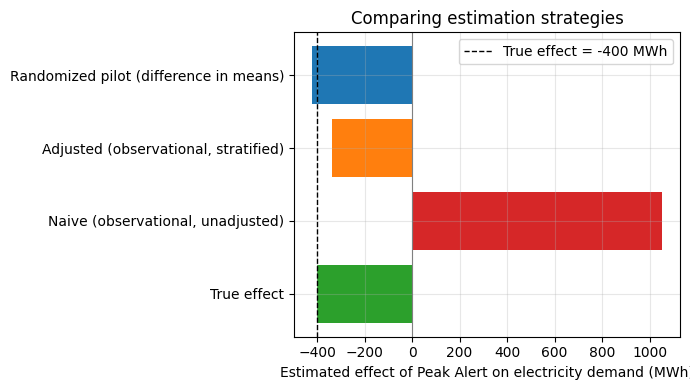

,Method,Estimate (MWh)
0,True effect,-400.000000
1,"Naive (observational, unadjusted)",1053.964262
2,"Adjusted (observational, stratified)",-338.812191
3,Randomized pilot (difference in means),-422.068751


In [8]:

comparison_a = pd.DataFrame({
    'Method': ['True effect', 'Naive (observational, unadjusted)',
               'Adjusted (observational, stratified)', 'Randomized pilot (difference in means)'],
    'Estimate (MWh)': [TRUE_ALERT_EFFECT, naive_alert_effect, adjusted_alert_effect, rct_effect]
})
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4']
ax.barh(comparison_a['Method'], comparison_a['Estimate (MWh)'], color=colors)
ax.axvline(TRUE_ALERT_EFFECT, color='black', linestyle='--', linewidth=1,
           label=f'True effect = {TRUE_ALERT_EFFECT} MWh')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Estimated effect of Peak Alert on electricity demand (MWh)')
ax.set_title('Comparing estimation strategies')
ax.legend()
plt.tight_layout()
plt.show()
comparison_a



Notice the naive estimate isn't just biased in magnitude — it has the
**wrong sign entirely**. This is a strong illustration of why the book
calls confounders "the root of all evil" in causal inference (section
1.1.5): left unaddressed, they can make a genuinely effective program look
useless or harmful.



## Case Study B — Do smart thermostats actually reduce energy use?

### The scenario

A utility offers customers a **smart thermostat** (self-installed, opt-in).
A year later, the utility wants to know: does having a smart thermostat
**cause** lower monthly electricity consumption?

The catch: customers with **larger homes** use more electricity to begin
with, *and* are more likely to have gotten an energy audit recommending
(and covering the cost of) a smart thermostat. Home size is a confounder,
in the same structure as the training/tourism examples:

```
        Home size (confounder)
         /                  \
        v                    v
  Has smart thermostat --> Monthly electricity use
```


In [9]:

n = 6000

# Confounder: home size in square feet (1000-4000)
home_size = np.random.uniform(1000, 4000, size=n)

# Adoption probability rises with home size (larger homes -> more likely to get an audit + thermostat)
prob_thermostat = 1 / (1 + np.exp(-0.0018 * (home_size - 2500)))
has_thermostat = np.random.binomial(1, prob_thermostat)

# True causal effect of the smart thermostat: -60 kWh/month
TRUE_THERMOSTAT_EFFECT = -60

monthly_kwh = (
    300
    + 0.25 * home_size                  # bigger homes -> more baseline usage
    + TRUE_THERMOSTAT_EFFECT * has_thermostat   # <-- the causal effect we want to recover
    + np.random.normal(0, 60, size=n)
)

energy = pd.DataFrame({
    'home_size': home_size,
    'has_thermostat': has_thermostat,
    'monthly_kwh': monthly_kwh
})
energy.head()


,home_size,has_thermostat,monthly_kwh
0,1647.677576,0,717.561277
1,1347.010212,0,605.566635
2,3319.919991,1,1095.678557
3,3560.372111,1,1127.307737
4,3139.152207,1,1126.057989


In [10]:

naive_thermostat_effect = (energy.loc[energy.has_thermostat == 1, 'monthly_kwh'].mean()
                            - energy.loc[energy.has_thermostat == 0, 'monthly_kwh'].mean())

print(f"E[usage | has thermostat] = {energy.loc[energy.has_thermostat==1,'monthly_kwh'].mean():.1f} kWh")
print(f"E[usage | no thermostat]  = {energy.loc[energy.has_thermostat==0,'monthly_kwh'].mean():.1f} kWh")
print(f"Naive difference          = {naive_thermostat_effect:+.1f} kWh")
print(f"True causal effect        = {TRUE_THERMOSTAT_EFFECT:+.1f} kWh")


E[usage | has thermostat] = 998.6 kWh
E[usage | no thermostat]  = 800.8 kWh
Naive difference          = +197.8 kWh
True causal effect        = -60.0 kWh



Again the naive comparison is misleading — this time it can even show
thermostat households using **more** electricity on average (or a much
smaller reduction than reality), simply because thermostat adopters skew
toward bigger homes.


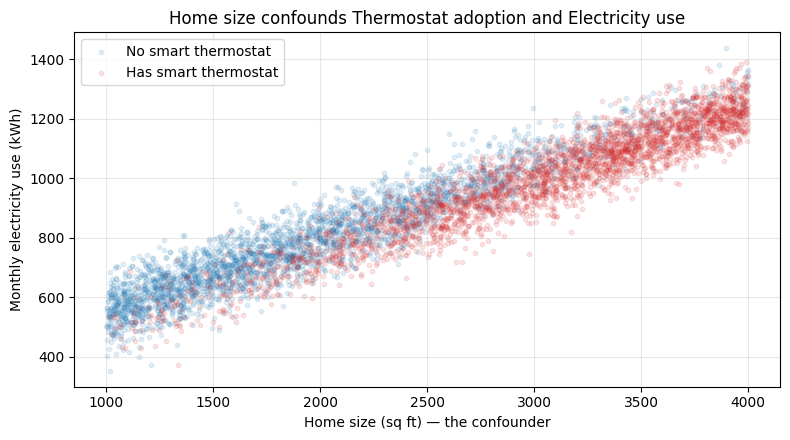

In [11]:

fig, ax = plt.subplots()
for t, color, label in [(0, '#1f77b4', 'No smart thermostat'), (1, '#d62728', 'Has smart thermostat')]:
    subset = energy[energy.has_thermostat == t]
    ax.scatter(subset.home_size, subset.monthly_kwh, alpha=0.12, s=10,
               color=color, label=label)
ax.set_xlabel('Home size (sq ft) — the confounder')
ax.set_ylabel('Monthly electricity use (kWh)')
ax.set_title('Home size confounds Thermostat adoption and Electricity use')
ax.legend()
plt.tight_layout()
plt.show()



### Adjusting for home size


In [12]:

energy['size_bin'] = pd.cut(energy.home_size, bins=10)

strata_b = (
    energy.groupby('size_bin', observed=True)
          .apply(lambda d: pd.Series({
              'n': len(d),
              'mean_thermostat': d.loc[d.has_thermostat == 1, 'monthly_kwh'].mean(),
              'mean_no_thermostat': d.loc[d.has_thermostat == 0, 'monthly_kwh'].mean(),
          }), include_groups=False)
)
strata_b['effect'] = strata_b['mean_thermostat'] - strata_b['mean_no_thermostat']
strata_b


,n,mean_thermostat,mean_no_thermostat,effect
size_bin,,,,
"(997.171, 1300.127]",590.0,535.768177,590.432847,-54.664671
"(1300.127, 1600.084]",572.0,601.445210,664.762532,-63.317322
"(1600.084, 1900.04]",585.0,682.326807,737.773721,-55.446914
"(1900.04, 2199.996]",570.0,757.729024,813.593844,-55.864820
"(2199.996, 2499.953]",581.0,833.450802,881.591072,-48.140270
"(2499.953, 2799.909]",621.0,899.081190,966.719218,-67.638028
"(2799.909, 3099.865]",619.0,976.234117,1035.841360,-59.607243
"(3099.865, 3399.822]",615.0,1055.699972,1105.404702,-49.704730
"(3399.822, 3699.778]",598.0,1129.140447,1183.243661,-54.103214


In [13]:

adjusted_thermostat_effect = np.average(strata_b['effect'].dropna(),
                                         weights=strata_b.loc[strata_b['effect'].notna(), 'n'])

print(f"Naive (unadjusted) difference = {naive_thermostat_effect:+.1f} kWh")
print(f"Adjusted (stratified) effect  = {adjusted_thermostat_effect:+.1f} kWh")
print(f"True causal effect            = {TRUE_THERMOSTAT_EFFECT:+.1f} kWh")


Naive (unadjusted) difference = +197.8 kWh
Adjusted (stratified) effect  = -55.8 kWh
True causal effect            = -60.0 kWh



### The gold standard: a randomized thermostat giveaway

Now suppose the utility instead ran a lottery: eligible customers are
**randomly** selected to receive a free smart thermostat, independent of
home size.


In [14]:

np.random.seed(17)
home_size_rct = np.random.uniform(1000, 4000, size=n)
has_thermostat_rct = np.random.binomial(1, 0.5, size=n)  # <-- randomized lottery

monthly_kwh_rct = (
    300
    + 0.25 * home_size_rct
    + TRUE_THERMOSTAT_EFFECT * has_thermostat_rct
    + np.random.normal(0, 60, size=n)
)

energy_rct = pd.DataFrame({'home_size': home_size_rct,
                            'has_thermostat': has_thermostat_rct,
                            'monthly_kwh': monthly_kwh_rct})

rct_thermostat_effect = (energy_rct.loc[energy_rct.has_thermostat == 1, 'monthly_kwh'].mean()
                          - energy_rct.loc[energy_rct.has_thermostat == 0, 'monthly_kwh'].mean())

print(f"Randomized lottery difference in means = {rct_thermostat_effect:+.1f} kWh")
print(f"True causal effect                      = {TRUE_THERMOSTAT_EFFECT:+.1f} kWh")


Randomized lottery difference in means = -69.6 kWh
True causal effect                      = -60.0 kWh


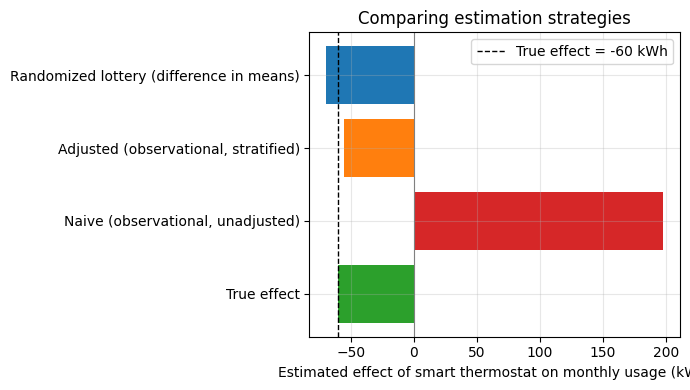

,Method,Estimate (kWh)
0,True effect,-60.000000
1,"Naive (observational, unadjusted)",197.780252
2,"Adjusted (observational, stratified)",-55.804392
3,Randomized lottery (difference in means),-69.579742


In [15]:

comparison_b = pd.DataFrame({
    'Method': ['True effect', 'Naive (observational, unadjusted)',
               'Adjusted (observational, stratified)', 'Randomized lottery (difference in means)'],
    'Estimate (kWh)': [TRUE_THERMOSTAT_EFFECT, naive_thermostat_effect,
                        adjusted_thermostat_effect, rct_thermostat_effect]
})
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4']
ax.barh(comparison_b['Method'], comparison_b['Estimate (kWh)'], color=colors)
ax.axvline(TRUE_THERMOSTAT_EFFECT, color='black', linestyle='--', linewidth=1,
           label=f'True effect = {TRUE_THERMOSTAT_EFFECT} kWh')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Estimated effect of smart thermostat on monthly usage (kWh)')
ax.set_title('Comparing estimation strategies')
ax.legend()
plt.tight_layout()
plt.show()
comparison_b



## Spurious correlation, energy edition

Section 1.4 of the book shows arcade revenue vs. computer-science PhDs —
strongly correlated, no direct causal link, both driven by population
growth. Here's an energy-flavored version: **home solar panel
installations** and **electric vehicle (EV) sales**, both climbing over
the same years, both driven by a hidden third factor — overall growth in
household disposable income and green-technology adoption.

```
        Green-tech adoption / income trend
              /                      \
             v                        v
   Solar panel installations      EV sales
```

No arrow runs directly between solar installations and EV sales — a
household doesn't buy an EV *because* it has solar panels (or vice versa)
— but if you only saw the two time series, the correlation might tempt you
to think one drives the other, e.g., "solar owners are buying EVs to use
their extra power," when the real driver is broader economic and
attitudinal change.


In [16]:

np.random.seed(5)
years = np.arange(2010, 2024)
green_trend = 100 + 25 * (years - 2010) + np.random.normal(0, 4, len(years))

solar_installations = 2 + 0.09 * (green_trend - 100) + np.random.normal(0, 1.0, len(years))   # thousands/year
ev_sales             = 5 + 0.22 * (green_trend - 100) + np.random.normal(0, 2.5, len(years))    # thousands/year

energy_spurious = pd.DataFrame({'year': years, 'solar_installations': solar_installations,
                                 'ev_sales': ev_sales})
corr = np.corrcoef(energy_spurious.solar_installations, energy_spurious.ev_sales)[0, 1]
print(f"Correlation between solar installations and EV sales: {corr:.3f}")


Correlation between solar installations and EV sales: 0.992


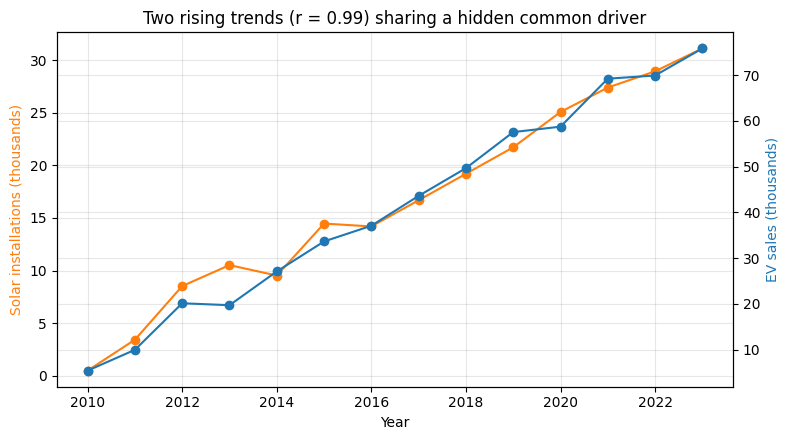

In [17]:

fig, ax1 = plt.subplots()
ax1.plot(energy_spurious.year, energy_spurious.solar_installations, color='#ff7f0e',
         marker='o', label='Solar installations (thousands)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Solar installations (thousands)', color='#ff7f0e')
ax2 = ax1.twinx()
ax2.plot(energy_spurious.year, energy_spurious.ev_sales, color='#1f77b4',
         marker='o', label='EV sales (thousands)')
ax2.set_ylabel('EV sales (thousands)', color='#1f77b4')
plt.title(f'Two rising trends (r = {corr:.2f}) sharing a hidden common driver')
plt.tight_layout()
plt.show()



Both series ride the same broader wave. A utility or automaker that
mistook this for a direct causal link might, for example, waste marketing
budget cross-promoting EVs to solar customers assuming a strong causal
lift, when the real growth driver is macro-level (income, policy
incentives, environmental attitudes).



## Conditional expectations recap

As in section 1.5.2, everything above is built from conditional
expectations, `E[Y | X]`. Let's compute the table by hand for the smart
thermostat case.


In [18]:

cond_exp = (
    energy.assign(size_group=pd.cut(energy.home_size, bins=[1000, 1750, 2500, 3250, 4000],
                                     labels=['1000-1750 sqft', '1750-2500 sqft',
                                             '2500-3250 sqft', '3250-4000 sqft']))
          .groupby(['size_group', 'has_thermostat'], observed=True)['monthly_kwh']
          .mean()
          .unstack('has_thermostat')
          .rename(columns={0: 'E[usage | no thermostat]', 1: 'E[usage | thermostat]'})
)
cond_exp['within-group effect (kWh)'] = (cond_exp['E[usage | thermostat]']
                                          - cond_exp['E[usage | no thermostat]'])
cond_exp


has_thermostat,E[usage | no thermostat],E[usage | thermostat],within-group effect (kWh)
size_group,,,
1000-1750 sqft,643.872620,602.635169,-41.237451
1750-2500 sqft,823.212066,787.137904,-36.074163
2500-3250 sqft,1007.700865,960.435432,-47.265433
3250-4000 sqft,1190.892290,1150.000866,-40.891424



Within every home-size band, thermostat households use roughly **60 kWh
less** per month — matching the true effect built into the data, and
confirming the stratified adjustment estimate is reliable.



## Exercises — extend this project

1. **Add a second confounder to Case Study B.** Add `home_age` (older
   homes are less insulated, use more energy, and might be *less* likely
   to have a smart thermostat installed). Does 1-D stratification on
   `home_size` alone still fully remove the bias?
2. **Humidity as a second confounder in Case Study A.** Humidity also
   drives A/C usage and may correlate with when alerts are issued. Add a
   `humidity` variable and check whether adjusting for temperature alone
   is enough.
3. **Regression-based adjustment.** Fit
   `monthly_kwh ~ has_thermostat + home_size` with `statsmodels.OLS` and
   compare the coefficient on `has_thermostat` to the stratified estimate.
   This previews the regression version of the adjustment formula from
   chapter 2.
4. **Sign-flipping confounders.** Modify Case Study A so that alerts are
   instead issued on **mild** days (e.g., for routine maintenance
   testing, not emergency conservation). Does the naive bias now push in
   the opposite direction?
5. **Design your own energy A/B test.** Pick a real utility intervention
   (e.g., time-of-use pricing, a home energy report comparing you to
   neighbors, EV charging incentives) and sketch: what's the treatment,
   what's the outcome, and what's the most likely confounder if you only
   had observational data?

## Summary

- Confounding bias doesn't always inflate an effect — as in Case Study A,
  it can **hide a real effect or even flip its apparent sign**, which is
  especially dangerous when deciding whether a conservation program
  "works."
- Cross-sectional adoption questions (smart thermostats, insulation
  upgrades, rooftop solar) are frequently confounded by underlying
  property characteristics like home size or age.
- Stratifying/adjusting for the confounder recovers estimates close to
  the true causal effect; a properly randomized pilot or lottery recovers
  it without any adjustment at all.
- Two energy-sector trends can rise together strongly (solar
  installations vs. EV sales) purely because of a shared macro driver —
  not because one causes the other.
